___
<img style="float: right; margin: 15px 15px 15px 15px;" src="https://media.gq-magazine.co.uk/photos/5e662a63b4e1880008727a40/16:9/w_2560%2Cc_limit/20200309-F1-Round-Up-01.jpg" width="380px" height="200px" />


# <font color= #bbc28d> **Modelo SARIMA - F1 [Weather]** </font>
#### <font color= #2E9AFE> `Tarea 3 - MNLP`</font>
- <Strong> Diana Valdivia, Samantha Sanchez, Clara Aguilar & Daniela de la Torre. </Strong>
- <Strong> Fecha </Strong>: 20/02/2026.

___

<p style="text-align:right;"> Image retrieved from: https://media.gq-magazine.co.uk/photos/5e662a63b4e1880008727a40/16:9/w_2560%2Cc_limit/20200309-F1-Round-Up-01.jpg</p>



Importamos as librerías necesarias

In [ ]:
from urllib.request import urlopen
import json
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


# <font color=#bbc28d> **Datos Iniciales** </font>
Este dataset contiene información meteorológica registrada durante un evento de **Formula 1**, obtenida a través de la OpenF1 API.
Incluye variables como temperatura del aire, temperatura de la pista, velocidad del viento, humedad y precipitación, las cuales influyen directamente en las condiciones de carrera y la toma de decisiones estratégicas.

In [ ]:
url = "https://api.openf1.org/v1/weather?meeting_key=1208"
response = urlopen(url)
data = json.loads(response.read().decode("utf-8"))

df = pd.DataFrame(data)

df.head(10)

,date,session_key,meeting_key,wind_direction,air_temperature,humidity,pressure,rainfall,wind_speed,track_temperature
0,2023-05-05T17:46:30.637000+00:00,9071,1208,143,29.4,46.0,1017.7,0,2.2,48.7
1,2023-05-05T17:47:30.636000+00:00,9071,1208,132,29.4,47.0,1017.9,0,2.0,49.1
2,2023-05-05T17:48:30.651000+00:00,9071,1208,140,29.3,48.0,1017.7,0,4.0,50.0
3,2023-05-05T17:49:30.635000+00:00,9071,1208,140,29.4,49.0,1017.7,0,3.7,49.1
4,2023-05-05T17:50:30.634000+00:00,9071,1208,134,29.4,49.0,1017.7,0,4.1,49.1
5,2023-05-05T17:51:30.649000+00:00,9071,1208,131,29.4,49.0,1017.7,0,2.7,48.4
6,2023-05-05T17:52:30.648000+00:00,9071,1208,138,29.2,50.0,1017.7,0,2.5,47.6
7,2023-05-05T17:53:30.648000+00:00,9071,1208,132,29.1,49.0,1017.7,0,3.9,48.7
8,2023-05-05T17:54:30.647000+00:00,9071,1208,137,29.1,48.0,1017.7,0,3.2,48.7
9,2023-05-05T17:55:30.646000+00:00,9071,1208,144,29.3,48.0,1017.7,0,2.7,48.7


Realizamos un procesamiento rapido de los datos como los tipos de columnas y nuestra variable a predecir:

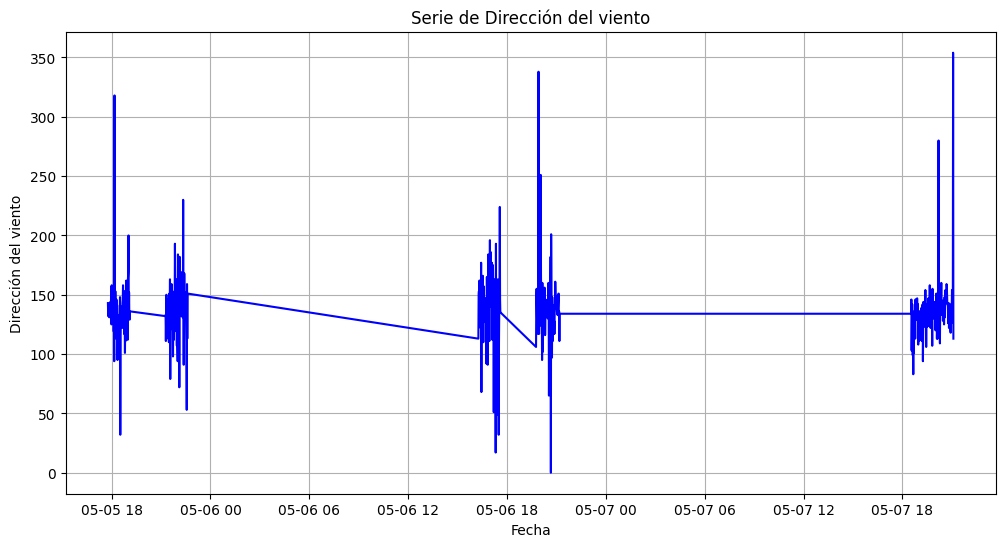

In [ ]:
# Preparar la serie
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df.set_index('date', inplace=True)

y = df['wind_direction']

plt.figure(figsize=(12,6))
plt.plot(y, color='blue')
plt.title("Serie de Dirección del viento")
plt.xlabel("Fecha")
plt.ylabel("Dirección del viento")
plt.grid(True)
plt.show()

La serie de tiempo de la dirección del viento muestra que, durante el periodo analizado, la mayoría de los valores se mantienen entre 100° y 160°, lo que indica que el viento sopla casi siempre en una dirección parecida. No se nota una tendencia clara hacia arriba o hacia abajo, y los cambios parecen mantenerse dentro de un rango similar, así que a simple vista podría decirse que el comportamiento es relativamente estable. Sin embargo, también aparecen algunos picos que llegan cerca de 0° y 350°, lo que parece un cambio muy fuerte. Aun así, hay que recordar que la dirección del viento es una variable circular: 0° y 360° prácticamente significan lo mismo. Por eso, algunos saltos que se ven muy grandes en la gráfica pueden no ser cambios tan bruscos en la realidad, sino simplemente una cuestión de cómo se representan los ángulos en una escala normal.

## **Estacionariedad** 
Un supuesto que se tiene al trabajar con modelos **SARIMA** es la estacionariedad, la cuál es la propiedad que mantiene media, varianza y autocovarianza constantes a lo largo del tiempo.

Para validar si una serie de tiempo es estacionaria, se realizan las siguientes pruebas:
- Augmented Dickey-Fuller (ADF)
  - Si el **p-value es menor a 0.05** la serie es **ESTACIONARIA.**
  - Si el **critical value es menor al test statistic** la serie es **ESTACIONARIA.**

In [ ]:
# Pruebas de estacionariedad y ACF/PACF
# Dickey-Fuller test
from statsmodels.tsa.stattools import adfuller
result = adfuller(y.dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -5.91485038390953
p-value: 2.5872887558104944e-07


En este caso, el estadístico obtenido fue -5.91 y el p-value fue 0.000000258, que es un valor muy pequeño y menor a 0.05. Esto significa que se puede rechazar la hipótesis de que la serie no es estacionaria. En palabras más simples, los resultados indican que la serie sí es estacionaria, ya que no presenta una tendencia clara ni cambios fuertes en su comportamiento a lo largo del tiempo. Por lo tanto, en teoría no sería necesario aplicar una diferenciación antes de usar un modelo como SARIMA.

## **Orden del Modelo (p,q)**
- **La función de autocorrelación (ACF)** entrega valores entre 1 y -1. Con la ACF, se puede evaluar la aleatoriedad y la estacionariedad de una serie temporal. También se puede determinar la presencia de tendencias y patrones estacionales.
- **La función de autocorrelación parcial (PACF)** aísla la correlación directa entre una observación y un rezago específico. La PACF es particularmente útil para determinar el orden de un modelo autorregresivo (AR).

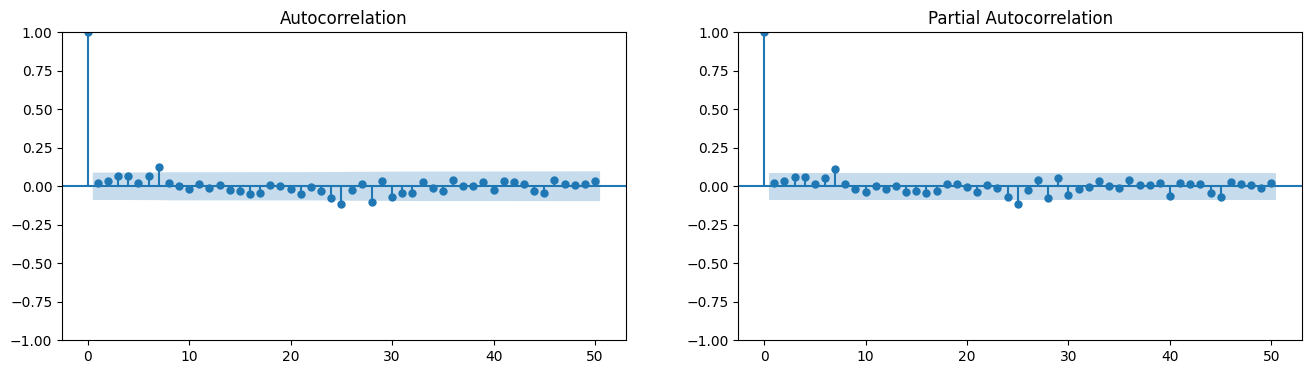

In [ ]:
# Graficar ACF y PACF
fig, axes = plt.subplots(1,2, figsize=(16,4))
plot_acf(y.dropna(), ax=axes[0], lags=50)
plot_pacf(y.dropna(), ax=axes[1], lags=50)
plt.show()

 En este caso, después del primer punto (rezago 0), casi todos los valores se mantienen dentro del rango de confianza, lo que indica que no hay relaciones fuertes entre los datos actuales y los anteriores. En palabras más simples, la serie no muestra un patrón claro de dependencia en el tiempo y parece comportarse de manera bastante aleatoria. Esto sugiere que no hay una estructura marcada que indique la necesidad de incluir muchos términos autorregresivos o de medias móviles en un modelo como SARIMA.

Una vez determinado el orden del modelo, pasamos a realizarlo:

In [ ]:
# Train/Test split
train_size = int(len(y) * 0.8)
train, test = y.iloc[:train_size], y.iloc[train_size:]

## **Modelar toda la serie**
Crearemos nuestro modelo de toda la serie:

In [ ]:
# Ajustar modelo SARIMA
model = sm.tsa.statespace.SARIMAX(train,
                                  order=(1,0,1),
                                  seasonal_order=(1,0,1,24),
                                  enforce_stationarity=False,
                                  enforce_invertibility=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
results = model.fit()
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                     wind_direction   No. Observations:                  389
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 24)   Log Likelihood               -1748.208
Date:                            Sat, 21 Feb 2026   AIC                           3506.416
Time:                                    23:26:59   BIC                           3525.888
Sample:                                         0   HQIC                          3514.156
                                            - 389                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.000   3517.488      0.000       0.999       1.001
ma.L1         -0.9744      0.011   

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


El modelo SARIMAX(1,0,1)x(1,0,1,24) fue ajustado a la serie de dirección del viento con 389 observaciones. Los coeficientes AR(1) y MA(1) resultaron estadísticamente significativos (p < 0.05), lo que indica que existe cierta relación con valores pasados inmediatos. Sin embargo, los componentes estacionales (lag 24) no fueron significativos, ya que sus p-values son altos, lo que sugiere que no hay evidencia clara de un patrón estacional fuerte cada 24 periodos. 

La prueba de Ljung-Box muestra un p-value alto (0.76), indicando que no quedan autocorrelaciones importantes en los residuos, lo cual es positivo. No obstante, la prueba Jarque-Bera indica que los residuos no siguen una distribución normal (p = 0.00) y presentan alta curtosis, lo que significa que existen valores extremos. En general, el modelo capta parte de la dinámica de la serie, pero la estacionalidad no parece ser relevante y los residuos muestran cierta desviación de normalidad.

In [ ]:
# Pronóstico sobre el test
pred = results.get_forecast(steps=len(test))
pred_ci = pred.conf_int()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
# Métricas
y_pred = pred.predicted_mean
mae = mean_absolute_error(test, y_pred)
rmse = np.sqrt(mean_squared_error(test, y_pred))
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 14.014107121843146
RMSE: 29.913590746188927


### **Evaluación del primer modelo**

El MAE indica que, en promedio, el modelo se equivoca alrededor de 14 grados al predecir la dirección del viento. Por otro lado, el RMSE es mayor porque penaliza más los errores grandes, lo que sugiere que en algunos puntos el modelo cometió errores considerablemente altos. En general, el modelo tiene un error promedio moderado, pero la diferencia entre MAE y RMSE muestra que existen algunas predicciones con desviaciones importantes respecto a los valores reales.

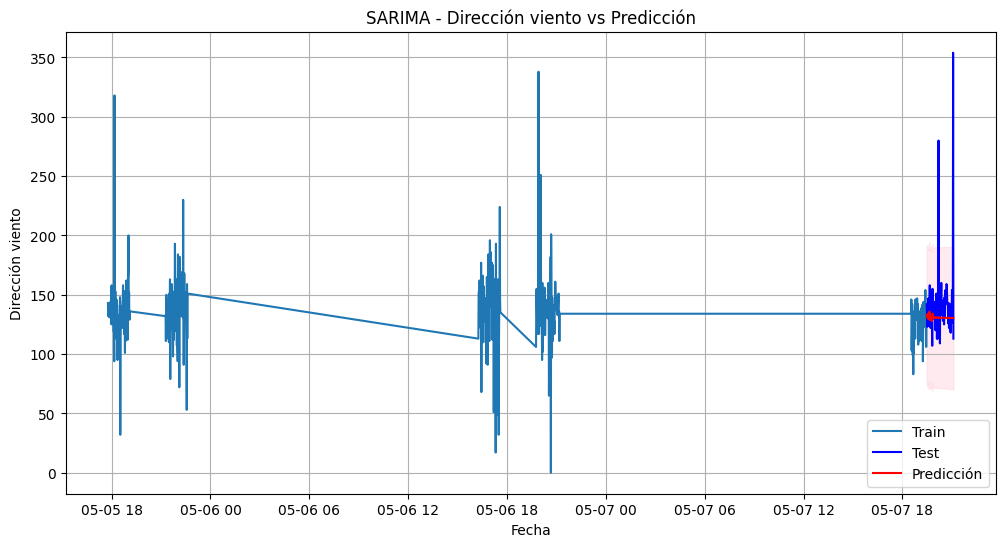

In [ ]:
# Gráfica predicción vs datos reales
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test", color="blue")
plt.plot(test.index, y_pred, label="Predicción", color="red")
plt.fill_between(test.index,
                 pred_ci.iloc[:,0],
                 pred_ci.iloc[:,1], color="pink", alpha=0.3)
plt.title("SARIMA - Dirección viento vs Predicción")
plt.xlabel("Fecha")
plt.ylabel("Dirección viento")
plt.legend()
plt.grid(True)
plt.show()

## **Modelar una fecha en el evento**
Como podemos ver, la mejor predicción que podía realizar el modelo era el promedio, por lo que para mejorarlo, decidimos modelar solo un día del evento:

## **Modelo 2**

In [ ]:
# Filtrar un solo día
df_day = df.loc['2023-05-05']

y = df_day['wind_direction']

Volvemos a realizar nuestra prueba de ADF:

In [ ]:
# ADF
result = adfuller(y.dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -13.550938511099352
p-value: 2.410198588165016e-25


Esto indica que al analizar solo un día, la serie es claramente estacionaria, incluso más que cuando se analizaba el periodo completo. Esto tiene sentido, ya que en un intervalo de tiempo más corto es menos probable que existan cambios estructurales o variaciones grandes en el comportamiento de la serie.

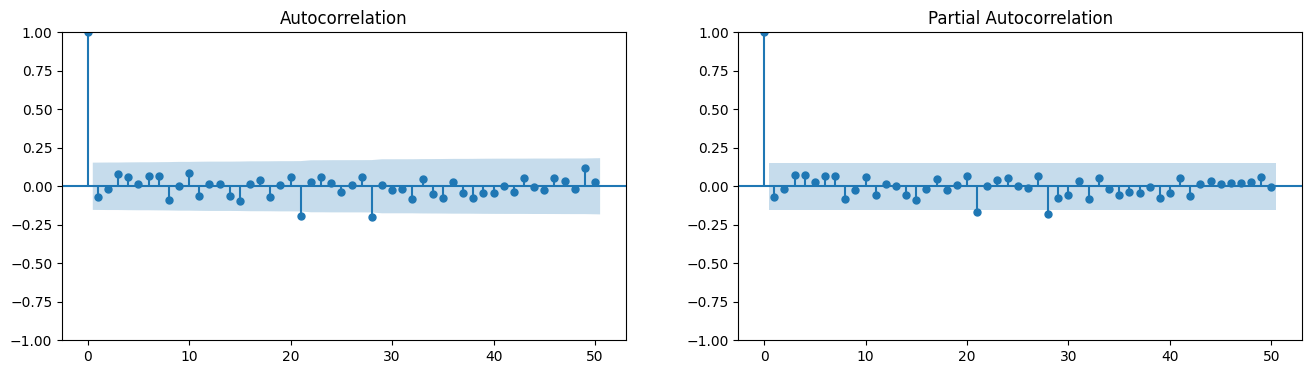

In [ ]:
# ACF
fig, axes = plt.subplots(1,2, figsize=(16,4))
plot_acf(y.dropna(), ax=axes[0], lags=50)
plot_pacf(y.dropna(), ax=axes[1], lags=50)
plt.show()

En la imagen se observa que, excepto el primer rezago (que siempre es 1), la mayoría de los puntos se mantienen dentro del intervalo de confianza, lo que indica que no existen correlaciones fuertes en los rezagos siguientes. Básicamente se podría decir que la serie no muestra un patrón claro de dependencia en el tiempo y parece comportarse de forma bastante aleatoria durante ese día.

In [ ]:
# Train/Test split
train_size = int(len(y) * 0.8)
train = y.iloc[:train_size]
test = y.iloc[train_size:]

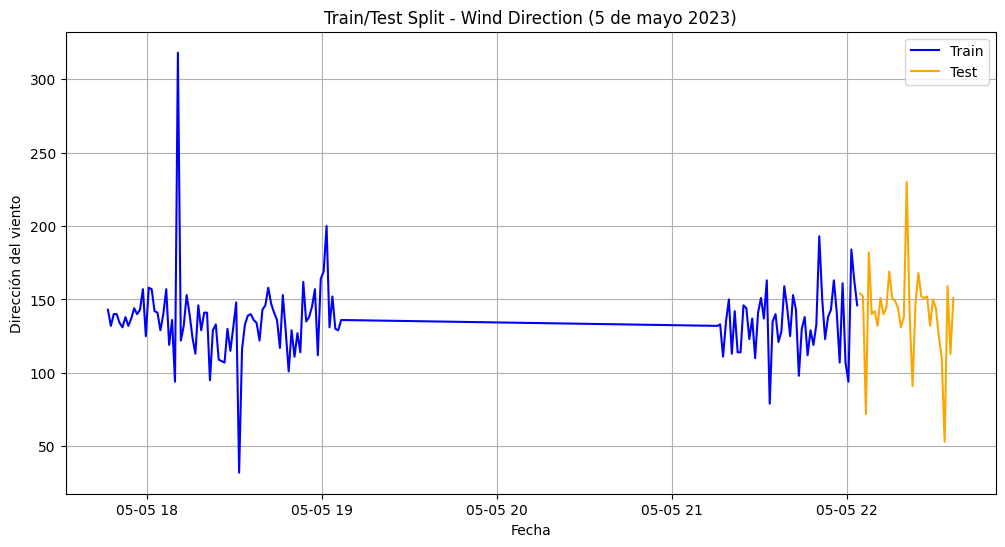

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Train", color="blue")
plt.plot(test.index, test, label="Test", color="orange")
plt.title("Train/Test Split - Wind Direction (5 de mayo 2023)")
plt.xlabel("Fecha")
plt.ylabel("Dirección del viento")
plt.legend()
plt.grid(True)
plt.show()

Se observa que ambos conjuntos mantienen un comportamiento similar, con variaciones y algunos picos, lo que ayuda a comprobar si el modelo logra adaptarse correctamente a esas fluctuaciones en la fase de prueba.

In [ ]:
# Modelo SARIMA ---
model = sm.tsa.statespace.SARIMAX(train,
                                  order=(1,0,1),
                                  seasonal_order=(1,0,1,60), # ciclo horario
                                  enforce_stationarity=False,
                                  enforce_invertibility=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
results = model.fit()
print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                     wind_direction   No. Observations:                  130
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 60)   Log Likelihood                -308.376
Date:                            Sat, 21 Feb 2026   AIC                            626.751
Time:                                    23:27:07   BIC                            637.849
Sample:                                         0   HQIC                           631.149
                                            - 130                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0009      0.001   1121.219      0.000       0.999       1.003
ma.L1         -1.0000      0.341   

En este segundo modelo SARIMAX(1,0,1)x(1,0,1,60), ajustado con 130 observaciones, los coeficientes AR(1) y MA(1) resultaron estadísticamente significativos (p < 0.05), lo que indica que existe relación con los valores inmediatamente anteriores. Sin embargo, los componentes estacionales con rezago 60 no son significativos, ya que sus p-values son altos, lo que sugiere que no hay evidencia clara de un patrón estacional fuerte cada 60 periodos. 

La prueba de Ljung-Box tiene un p-value alto (0.90), lo que indica que los residuos no presentan autocorrelación importante y el modelo logró capturar bien la dependencia temporal. Además, la prueba Jarque-Bera muestra un p-value alto (0.76), lo que significa que los residuos se aproximan a una distribución normal. En general, este segundo modelo parece ajustarse mejor en términos de comportamiento de los residuos.

In [ ]:
# Pronóstico
pred = results.get_forecast(steps=len(test))
y_pred = pred.predicted_mean
test_aligned = test.iloc[:len(y_pred)]  # longitudes iguales

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
# Métricas
mae = mean_absolute_error(test_aligned, y_pred)
rmse = np.sqrt(mean_squared_error(test_aligned, y_pred))
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 19.29538760518001
RMSE: 28.69312559290251


Esto significa que, en promedio, el modelo se equivoca alrededor de 19 grados al predecir la dirección del viento. El RMSE es un poco mayor porque penaliza más los errores grandes, lo que indica que existen algunas predicciones con desviaciones más fuertes.

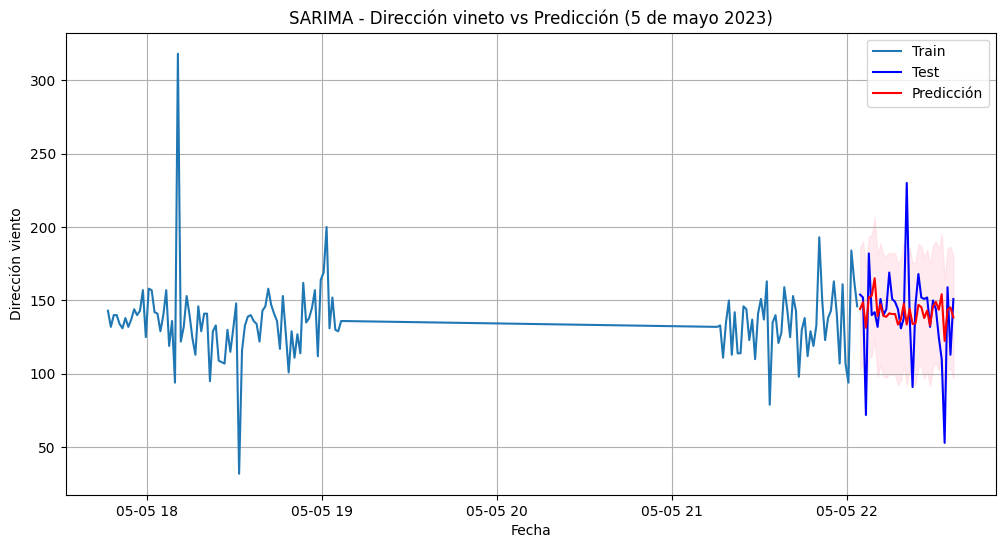

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test", color="blue")
plt.plot(test_aligned.index, y_pred, label="Predicción", color="red")
plt.fill_between(test_aligned.index,
                 pred.conf_int().iloc[:,0],
                 pred.conf_int().iloc[:,1],
                 color="pink", alpha=0.3)
plt.title("SARIMA - Dirección viento vs Predicción (5 de mayo 2023)")
plt.xlabel("Fecha")
plt.ylabel("Dirección viento")
plt.legend()
plt.grid(True)
plt.show()


La gráfica muestra la comparación entre los datos reales y las predicciones generadas por el segundo modelo SARIMA para el 5 de mayo de 2023. La línea azul clara corresponde a los datos utilizados para entrenar el modelo, mientras que la azul más oscura representa los valores reales del conjunto de prueba. La línea roja indica las predicciones del modelo y el área sombreada muestra el intervalo de confianza. Se observa que el modelo sigue de manera general el nivel promedio de la serie, pero no logra capturar completamente los picos y caídas bruscas que aparecen en los datos reales. Esto indica que, aunque el modelo reproduce el comportamiento general, todavía tiene dificultades para ajustarse a las variaciones más fuertes en la dirección del viento.

## **Modelo 3**
Ahora intentaremos cambiar la parte de estacionalidad al ciclo horario para ver si mejora:

In [ ]:
# Modelo SARIMA ---
model = sm.tsa.statespace.SARIMAX(train,
                                  order=(1,0,1),
                                  seasonal_order=(1,0,2,60), # ciclo horario
                                  enforce_stationarity=False,
                                  enforce_invertibility=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
results = model.fit()
print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                        SARIMAX Results                                        
Dep. Variable:                          wind_direction   No. Observations:                  130
Model:             SARIMAX(1, 0, 1)x(1, 0, [1, 2], 60)   Log Likelihood                 -35.447
Date:                                 Sat, 21 Feb 2026   AIC                             82.894
Time:                                         23:29:14   BIC                             83.371
Sample:                                              0   HQIC                            79.679
                                                 - 130                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0208      1.129      0.018      0.985      -2.192       2

Se observa que varios coeficientes no son estadísticamente significativos, ya que presentan p-values muy altos (cercanos a 1), lo que indica que esos términos no aportan realmente al modelo. Además, algunos errores estándar son extremadamente grandes, lo que sugiere inestabilidad en la estimación de los parámetros. Sin embargo, el componente autoregresivo estacional en el rezago 60 sí resulta significativo (p < 0.05), lo que indica cierta relación estacional en ese periodo. 

Las pruebas de diagnóstico muestran un p-value alto en Ljung-Box (0.63), lo que indica que no hay autocorrelación importante en los residuos, y un p-value alto en Jarque-Bera (0.84), lo que sugiere que los residuos se aproximan a la normalidad. Aunque el AIC es mucho más bajo que en los modelos anteriores, la falta de significancia en varios parámetros indica que el modelo puede estar sobreajustado o mal especificado.

In [ ]:
# Pronóstico
pred = results.get_forecast(steps=len(test))
y_pred = pred.predicted_mean
test_aligned = test.iloc[:len(y_pred)]  # longitudes iguales

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
# Métricas
mae = mean_absolute_error(test_aligned, y_pred)
rmse = np.sqrt(mean_squared_error(test_aligned, y_pred))
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 22.83904666581459
RMSE: 31.93462322968483


Esto significa que, en promedio, el modelo se equivoca alrededor de 23 grados al predecir la dirección del viento. El RMSE es aún mayor porque penaliza más los errores grandes, lo que indica que existen algunas predicciones con desviaciones bastante fuertes. En comparación con los modelos anteriores, este modelo presenta errores más altos, lo que sugiere que, aunque su AIC era más bajo, en la práctica no está prediciendo mejor en el conjunto de prueba.

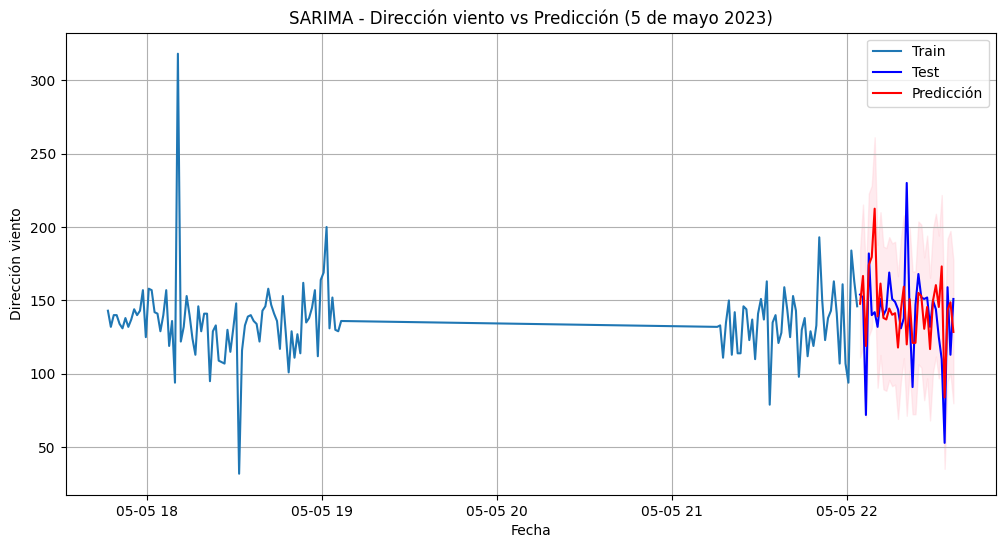

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test", color="blue")
plt.plot(test_aligned.index, y_pred, label="Predicción", color="red")
plt.fill_between(test_aligned.index,
                 pred.conf_int().iloc[:,0],
                 pred.conf_int().iloc[:,1],
                 color="pink", alpha=0.3)
plt.title("SARIMA - Dirección viento vs Predicción (5 de mayo 2023)")
plt.xlabel("Fecha")
plt.ylabel("Dirección viento")
plt.legend()
plt.grid(True)
plt.show()

## **Conclusión**

Para finalizar la serie es estacionaria según la prueba ADF, los modelos con menor AIC no necesariamente presentan mejor desempeño predictivo, en resumen, el Modelo 1 tiene el MAE más bajo (14.01) sobre toda la serie, lo que lo hace el mejor predictor en términos de error absoluto. Sin embargo, si se trabaja únicamente con datos de un día de evento, el Modelo 2 es preferible al Modelo 3, ya que tiene mejor desempeño predictivo fuera de muestra a pesar de que el Modelo 3 tiene un AIC mejor en entrenamiento.